#**Analysis of the Tender Process in Public Procurement**

#**Problem Statement**

* Analyze tender performance across different stages (AOC, evaluation, cancelled, bidding)

* Identify delays and bottlenecks in the tender process

* Understand variation in tender values across categories, methods, contract types, and buyers

* Analyze trends in tender values over time and across stages

* Address data quality issues like missing values, duplicates, and unrealistic entries

#**Objective**

The objective of this analysis is to evaluate the efficiency and performance of the tender process by examining different stages and identifying delays. It also aims to understand patterns in tender values across categories, methods, and buyers, while ensuring data quality for reliable insights.

# **Domain**

Domain of this project is Public Procurement Analytics


# **Outcome**

* Clear understanding of tender process performance based on stage-wise distribution (AOC, cancelled, pending)

* Identification of key factors influencing high-value tenders (category, method, contract type, buyer)

* Insights into bottleneck stages where tenders are not progressing toward finalization

* Understanding of how tender duration varies across categories and values

* Identification of time-based trends in tender activity and value growth

* Actionable insights to support better tender planning and decision-making

# **Dataset information**

**Source:** https://delhi.data.gov.in/resource/assam-public-procurement-data-2021-22

**File size:** 2.2 MB

**Year / Timeline:** Data collected during 2021 to 2022 Published On:
11/10/2022

The dataset represents a snapshot of tender data as of 28-09-2021.

**Dataset Column/features Description:**

* **OCID** - Open Contracting ID (Unique Identifier)

* **tender_title** - Name/ title of the tender

* **main_procurement_category** - Type(Works, Goods, Services)

* **tender_procurement_method** - Method used (Open tender, Limited,etc)

* **tender_contract_type** - Contract type (Item Rate, Lump Sum, etc.)

* **tender_classification** - Description of work (e.g., Civil Works – Roads)

* **allow_two_stage_tender** - If 2-stage bidding is allowed (Yes/No)

* **tender_value** - Estimated cost of project

* **date_published** - Date of tender was published

* **tender_Period_in_days** - Total duration (in days)

* **tender_stage** - Current stage (Technical Bid, Financial Bid, etc.)

* **number_of_tenderers** - Number of bidders

* **bid_opening_date** - Date when bids are opened

* **buyer_name** - Department/Organization issuing tender


# **Note For Kind of Analysis to be done**

* The dataset is first explored to understand the overall structure of tenders, including categories, procurement methods, values, buyers, and stages, to get a clear picture of how tenders are distributed across the system

* Patterns are then examined to understand why certain tenders have higher values, focusing on factors such as procurement category, contract type, and buyer, along with identifying reasons for cancellations, retenders, or delays in specific stages

* Based on observed patterns, trends over time are analyzed to estimate how tender values and stages progress, identifying categories with higher values and stages with potential delays or low conversion.

* Finally, insights are used to suggest improvements in the tender process, such as optimizing tender duration, selecting appropriate procurement methods, and identifying areas where delays can be reduced to improve overall process performance

# **Stages for DA Project**

## **Stage 1 – Problem Definition and Dataset Selection**




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("https://github.com/rajespriya1-pixel/Procurement-Data-2021-22/raw/refs/heads/main/ocds_mapped_procurement_data_fiscal_year_2021_2022.csv")

In [ ]:
df.shape

(4690, 34)

In [ ]:
df=df.copy()

In [ ]:
df

,ocid,initiationType,tag,id,date,tender/id,tender/externalReference,tender/title,tender/mainProcurementCategory,tender/procurementMethod,...,tender/status,tender/stage,tender/numberOfTenderers,tender/milestones/type.1,tender/milestones/title.1,tender/milestones/dueDate.1,tender/bidOpening/date,tender/documents/id,buyer/name,fiscal_year
0,ocds-kjhdrl-2021_PWD_19891_6,tender,tender,1,29-09-2022,2021_PWD_19891_6,TRC/SOPD-G/TEZPUR/2020-21,TRC/SOPD-G/BIS/06,Works,Open Tender,...,NaN,To be Opened,5.0,assessment,Price Bid Opening Date,NaN,19-01-2021 11:00,NaN,Public Works Roads Department,2021-2022
1,ocds-kjhdrl-2021_PWD_19891_9,tender,tender,1,29-09-2022,2021_PWD_19891_9,TRC/SOPD-G/TEZPUR/2020-21,TRC/SOPD-G/BIS/09,Works,Open Tender,...,NaN,Technical Bid Opening,3.0,assessment,Price Bid Opening Date,NaN,19-01-2021 11:00,NaN,Public Works Roads Department,2021-2022
2,ocds-kjhdrl-2021_NHM_19920_1,tender,tender,1,29-09-2022,2021_NHM_19920_1,NHM-32049/1/2020-Construct,Renovation of existing BPHC Main Building New ...,Works,Open Tender,...,NaN,To be Opened,5.0,assessment,Price Bid Opening Date,NaN,27-01-2021 14:30,NaN,National Health Mission,2021-2022
3,ocds-kjhdrl-2021_PWD_19928_1,tender,tender,1,29-09-2022,2021_PWD_19928_1,SOPD-G/2020-21/S AND J/EE/03,SOPD-G/2020-21/S AND J/EE/03,Works,Open Tender,...,NaN,Financial Bid Opening,2.0,assessment,Price Bid Opening Date,NaN,13-01-2021 12:00,NaN,Public Works Roads Department,2021-2022
4,ocds-kjhdrl-2021_SSA_19927_1,tender,tender,1,29-09-2022,2021_SSA_19927_1,SSA_PrePri_Proc_36_2020_3755,SUPPLY OF TLM KIT,Goods,Open Tender,...,NaN,To be Opened,6.0,assessment,Price Bid Opening Date,NaN,27-01-2021 15:00,NaN,Axom Sarba Siksha Abhijan Mission,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4685,ocds-kjhdrl-2021_NHM_22154_12,tender,tender,1,29-09-2022,2021_NHM_22154_12,NHM/C-CW/32050/15/2020-Cons/51,Repairing Renovation of 210 Nos of Subcentres ...,Works,Open Tender,...,NaN,AOC,1.0,assessment,Price Bid Opening Date,NaN,21-07-2021 16:00,NaN,National Health Mission,2021-2022
4686,ocds-kjhdrl-2022_PWD_24133_1,tender,tender,1,29-09-2022,2022_PWD_24133_1,EGTRD /GCD-1/ TB-1/ 2019-20/5490,EGTRD-02,Works,Open Tender,...,NaN,Financial Bid Opening,NaN,assessment,Price Bid Opening Date,NaN,04-02-2022 11:00,NaN,Public Works Roads Department,2021-2022
4687,ocds-kjhdrl-2021_APDCL_22899_1,tender,tender,1,29-09-2022,2021_APDCL_22899_1,APDCL/DDU-New/NRE/Pkg-17,Off Grid rural electrification works in distri...,Works,Open Tender,...,NaN,Technical Evaluation,NaN,assessment,Price Bid Opening Date,NaN,30-10-2021 11:00,NaN,Assam Power Distribution Company Ltd,2021-2022
4688,ocds-kjhdrl-2022_ICD_25845_1,tender,tender,1,29-09-2022,2022_ICD_25845_1,AGCL/F AND A/2019/CR/II,ENGAGEMENT OF RBI APPROVED CREDIT RATING AGENCIES,Services,Open Tender,...,NaN,Technical Evaluation,NaN,assessment,Price Bid Opening Date,NaN,20-06-2022 14:30,NaN,Industries and Commerce Department,2021-2022


In [ ]:
df.head(3)

,ocid,initiationType,tag,id,date,tender/id,tender/externalReference,tender/title,tender/mainProcurementCategory,tender/procurementMethod,...,tender/status,tender/stage,tender/numberOfTenderers,tender/milestones/type.1,tender/milestones/title.1,tender/milestones/dueDate.1,tender/bidOpening/date,tender/documents/id,buyer/name,fiscal_year
0,ocds-kjhdrl-2021_PWD_19891_6,tender,tender,1,29-09-2022,2021_PWD_19891_6,TRC/SOPD-G/TEZPUR/2020-21,TRC/SOPD-G/BIS/06,Works,Open Tender,...,NaN,To be Opened,5.0,assessment,Price Bid Opening Date,NaN,19-01-2021 11:00,NaN,Public Works Roads Department,2021-2022
1,ocds-kjhdrl-2021_PWD_19891_9,tender,tender,1,29-09-2022,2021_PWD_19891_9,TRC/SOPD-G/TEZPUR/2020-21,TRC/SOPD-G/BIS/09,Works,Open Tender,...,NaN,Technical Bid Opening,3.0,assessment,Price Bid Opening Date,NaN,19-01-2021 11:00,NaN,Public Works Roads Department,2021-2022
2,ocds-kjhdrl-2021_NHM_19920_1,tender,tender,1,29-09-2022,2021_NHM_19920_1,NHM-32049/1/2020-Construct,Renovation of existing BPHC Main Building New ...,Works,Open Tender,...,NaN,To be Opened,5.0,assessment,Price Bid Opening Date,NaN,27-01-2021 14:30,NaN,National Health Mission,2021-2022


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 34 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   ocid                                            4690 non-null   object 
 1   initiationType                                  4690 non-null   object 
 2   tag                                             4690 non-null   object 
 3   id                                              4690 non-null   int64  
 4   date                                            4690 non-null   object 
 5   tender/id                                       4690 non-null   object 
 6   tender/externalReference                        4690 non-null   object 
 7   tender/title                                    4690 non-null   object 
 8   tender/mainProcurementCategory                  4690 non-null   object 
 9   tender/procurementMethod                 

In [ ]:
df.describe()

,id,tender/submissionMethodDetails,tender/milestones/dueDate,tender/tenderPeriod/durationInDays,tender/status,tender/numberOfTenderers,tender/milestones/dueDate.1
count,4690.0,0.0,0.0,4690.000000,0.0,2297.000000,0.0
mean,1.0,NaN,NaN,170.217484,NaN,5.344798,NaN
std,0.0,NaN,NaN,95.576874,NaN,37.252089,NaN
min,1.0,NaN,NaN,1.000000,NaN,0.000000,NaN
25%,1.0,NaN,NaN,120.000000,NaN,1.000000,NaN
50%,1.0,NaN,NaN,180.000000,NaN,2.000000,NaN
75%,1.0,NaN,NaN,180.000000,NaN,4.000000,NaN
max,1.0,NaN,NaN,999.000000,NaN,899.000000,NaN


In [ ]:
df.shape

(4690, 34)

In [ ]:
df.isnull().sum()

,0
ocid,0
initiationType,0
tag,0
id,0
date,0
tender/id,0
tender/externalReference,0
tender/title,0
tender/mainProcurementCategory,0
tender/procurementMethod,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **Stage 2 – Data Cleaning and Pre-processing**

# **Dropping unwanted columns**

In [ ]:
df = df.drop(['initiationType',
'tag',
'id',
'date',
'tender/id',
'tender/externalReference',
'tender/submissionMethodDetails',
'tender/participationFee/0/multiCurrencyAllowed',
'tender/milestones/title',
'tender/milestones/code',
'tender/milestones/type',
'tender/milestones/dueDate',
'tender/allowPreferentialBidder',
'Payment Mode',
'tender/status',
'tender/milestones/type.1',
'tender/milestones/title.1',
'tender/milestones/dueDate.1',
'tender/documents/id',
'fiscal_year'],
axis=1).copy()

In [ ]:
df.shape

(4690, 14)

In [ ]:
cols=df.columns
cols

Index(['ocid', 'tender/title', 'tender/mainProcurementCategory',
       'tender/procurementMethod', 'tender/contractType',
       'tenderclassification/description', 'tender/allowTwoStageTender',
       'tender/value/amount', 'tender/datePublished',
       'tender/tenderPeriod/durationInDays', 'tender/stage',
       'tender/numberOfTenderers', 'tender/bidOpening/date', 'buyer/name'],
      dtype='object')

# **Column Name Renaming**

In [ ]:
df.columns=df.columns.str.replace('tender/','')
df.columns

Index(['ocid', 'title', 'mainProcurementCategory', 'procurementMethod',
       'contractType', 'tenderclassification/description',
       'allowTwoStageTender', 'value/amount', 'datePublished',
       'tenderPeriod/durationInDays', 'stage', 'numberOfTenderers',
       'bidOpening/date', 'buyer/name'],
      dtype='object')

In [ ]:
df.rename(columns={
    'title':'tender_title',
    'mainProcurementCategory':'main_procurement_category',
    'procurementMethod':'procurement_method',
    'contractType':'contract_type',
    'tenderclassification/description':'tender_classification',
    'allowTwoStageTender':'allow_two_stage_tender',
    'value/amount':'tender_value',
    'datePublished':'date_published',
    'tenderPeriod/durationInDays':'tender_period_in_days',
    'stage':'tender_stage',
    'numberOfTenderers':'number_of_tenderers',
    'bidOpening/date':'bid_opening_date',
    'buyer/name':'buyer_name'

},inplace=True)

In [ ]:
df.columns

Index(['ocid', 'tender_title', 'main_procurement_category',
       'procurement_method', 'contract_type', 'tender_classification',
       'allow_two_stage_tender', 'tender_value', 'date_published',
       'tender_period_in_days', 'tender_stage', 'number_of_tenderers',
       'bid_opening_date', 'buyer_name'],
      dtype='object')

# **Checking Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

# **Checking Missing Values**

In [ ]:
df.isnull().sum()

,0
ocid,0
tender_title,0
main_procurement_category,0
procurement_method,0
contract_type,0
tender_classification,0
allow_two_stage_tender,0
tender_value,1166
date_published,0
tender_period_in_days,0


# **Handling Missing Values in Tender Value by drop**

In [ ]:
df = df[df['tender_value'].notna()].copy()

In [ ]:
df['tender_value'].isna().sum()

np.int64(0)

In [ ]:
df.shape

(3524, 14)

In [ ]:
df = df[df['tender_value'] != '0'].copy()

In [ ]:
df.shape

(3411, 14)

# **Handling Missing Values in Tender Stage by impute**

In [ ]:
df.loc[:,'tender_stage']=df['tender_stage'].fillna('unknown')

In [ ]:
df['tender_stage'].isna().sum()

np.int64(0)

# **Handling Missing Values in No of Tenderers**

In [ ]:
df['number_of_tenderers'].isnull().sum()

np.int64(1622)

About 48% of values are missing, so they are kept as null. Imputing with 0 or median may distort the data and lead to inaccurate insights.

# **Checking data types**

In [ ]:
df.dtypes

,0
ocid,object
tender_title,object
main_procurement_category,object
procurement_method,object
contract_type,object
tender_classification,object
allow_two_stage_tender,object
tender_value,object
date_published,object
tender_period_in_days,int64


# **Converting Data Types**

In [ ]:
df['allow_two_stage_tender']=(df['allow_two_stage_tender'].astype(str).str.strip().str.lower().map({'yes':True,'no':False}))

In [ ]:
df['allow_two_stage_tender'].dtype

dtype('bool')

In [ ]:
df['tender_value']=pd.to_numeric(df['tender_value'].astype(str).str.replace(',', '', regex=False))

In [ ]:
df['tender_value'].dtype

dtype('int64')

In [ ]:
df['date_published']=pd.to_datetime(df['date_published'],dayfirst=True)

In [ ]:
df['date_published'].dtype

dtype('<M8[ns]')

In [ ]:
df['bid_opening_date']=pd.to_datetime(df['bid_opening_date'],dayfirst=True)

In [ ]:
df['bid_opening_date'].dtype

dtype('<M8[ns]')

In [ ]:
df['number_of_tenderers'] = df['number_of_tenderers'].astype('Int64')

In [ ]:
df['number_of_tenderers'].dtype

Int64Dtype()

# **Validating Data Types**

In [ ]:
df.dtypes

,0
ocid,object
tender_title,object
main_procurement_category,object
procurement_method,object
contract_type,object
tender_classification,object
allow_two_stage_tender,bool
tender_value,int64
date_published,datetime64[ns]
tender_period_in_days,int64


# **Checking outliers in date fields**


In [ ]:
import numpy as np

In [ ]:
wrong_rows = df[df['bid_opening_date'] < df['date_published']]
wrong_rows.head(3)

,ocid,tender_title,main_procurement_category,procurement_method,contract_type,tender_classification,allow_two_stage_tender,tender_value,date_published,tender_period_in_days,tender_stage,number_of_tenderers,bid_opening_date,buyer_name
0,ocds-kjhdrl-2021_PWD_19891_6,TRC/SOPD-G/BIS/06,Works,Open Tender,Item Rate,Civil Works – Roads,False,11919684,2021-04-01 10:30:00,180,To be Opened,5,2021-01-19 11:00:00,Public Works Roads Department
1,ocds-kjhdrl-2021_PWD_19891_9,TRC/SOPD-G/BIS/09,Works,Open Tender,Item Rate,Civil Works – Roads,False,9548716,2021-04-01 10:30:00,180,Technical Bid Opening,3,2021-01-19 11:00:00,Public Works Roads Department
2,ocds-kjhdrl-2021_NHM_19920_1,Renovation of existing BPHC Main Building New ...,Works,Open Tender,Item Rate,Civil Works - Building,False,9992617,2021-04-01 12:00:00,180,To be Opened,5,2021-01-27 14:30:00,National Health Mission


In [ ]:
len(wrong_rows)

992

# **Handling outliers in date fields**

In [ ]:
df.loc[df['bid_opening_date'] < df['date_published'], 'bid_opening_date'] = np.nan

# **Checking Skewness on numerical values**

In [ ]:
df.select_dtypes(include='int64').skew()

,0
tender_value,14.563729
tender_period_in_days,6.16422
number_of_tenderers,2.308141


# **Handling Outliers in Tender (bidding) Period in days**

In [ ]:
#replacing outlier values as missing
df.loc[df['tender_period_in_days']>365,'tender_period_in_days']=np.nan

# **Validating Skewness of Tender Period**

In [ ]:
df['tender_period_in_days'].skew()

np.float64(-0.053184994271576976)

#**Handling Skewness and applying transformation in Tender Value & No of Tenderers**

In [ ]:
from sklearn.preprocessing import PowerTransformer

In [ ]:
pt = PowerTransformer(method='yeo-johnson')

In [ ]:
transformed_df = pt.fit_transform(df[['tender_value', 'number_of_tenderers']])
transformed_df

array([[-0.09456512,  1.0472347 ],
       [-0.23979519,  0.32383722],
       [-0.21001741,  1.0472347 ],
       ...,
       [-0.61676828, -0.9803885 ],
       [-1.11129539,         nan],
       [ 1.70865585,         nan]])

In [ ]:
# Assigning the result back to new columns in df
df[['tender_value_pt', 'number_of_tenderers_pt']] = transformed_df

#**Validating Skewness in Tender Value & No of Tenderers**

In [ ]:
df[['tender_value_pt', 'number_of_tenderers_pt']].skew()

,0
tender_value_pt,-0.013222
number_of_tenderers_pt,-0.003399


# **Feature transformations (date parts, derived fields)**

In [ ]:
df['process_duration']=(pd.to_datetime(df['bid_opening_date'])-pd.to_datetime(df['date_published'])).dt.days
df['process_duration'].head()

,process_duration
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


## **Stage 3 – EDA and Visualizations**


In [ ]:
df.nunique()

,0
ocid,3411
tender_title,3194
main_procurement_category,3
procurement_method,5
contract_type,12
tender_classification,50
allow_two_stage_tender,2
tender_value,2443
date_published,1214
tender_period_in_days,20


# **Unique Values overview in Categorical Columns**


In [ ]:
df['allow_two_stage_tender'].unique()

array([False,  True])

In [ ]:
df['main_procurement_category'].unique()

array(['Works', 'Goods', 'Services'], dtype=object)

In [ ]:
df['procurement_method'].unique()

array(['Open Tender', 'Limited', 'Open Limited', 'Single',
       'Global Tenders'], dtype=object)

In [ ]:
df['contract_type'].unique()

array(['Item Rate', 'Supply', 'Turn-key', 'Lump-sum', 'EOI', 'Works',
       'Buy', 'Percentage', 'Item Wise', 'Fixed-rate', 'QCBS',
       'Empanelment'], dtype=object)

In [ ]:
df['tender_classification'].unique()

array(['Civil Works – Roads', 'Civil Works - Building', 'Civil Works',
       'Supply of Materials', 'Miscellaneous Goods',
       'Electronics Equipment', 'Agricultural or Forestry',
       'Civil Works - Water Works', 'Miscellaneous Works',
       'Miscellaneous Services', 'Medical Equipments/Waste', 'Explosive',
       'Composite Works', 'Information Technology', 'Electrical Works',
       'Hotel/ Catering', 'Civil Works - Others',
       'Housekeeping/ Cleaning', 'Vehicles/Vehicle Spares',
       'Pipe Laying Works', 'Construction Works', 'Furniture/ Fixture',
       'Machineries', 'Civil Works – Highways',
       'Civil Works – Lift Irrigation Schemes', 'Publishing/Printing',
       'Architecture/Interior Design', 'Electrical Work/ Equipment',
       'Consultancy', 'Crop Products',
       'Power Tiller with Trailer and Accessories', 'Manpower Supply',
       'Farm Machinery and Equipments',
       'Laboratory and scientific equipment', 'Mechanical Engg Items',
       'Network /Com

In [ ]:
df['tender_stage'].unique()

array(['To be Opened', 'Technical Bid Opening', 'Financial Bid Opening',
       'Technical Evaluation', 'Financial Evaluation', 'AOC', 'Cancelled',
       'Retender', 'unknown'], dtype=object)

In [ ]:
df['tender_value_in_cr']=df['tender_value']/10000000

:# **Tender Value Distribution Analysis**

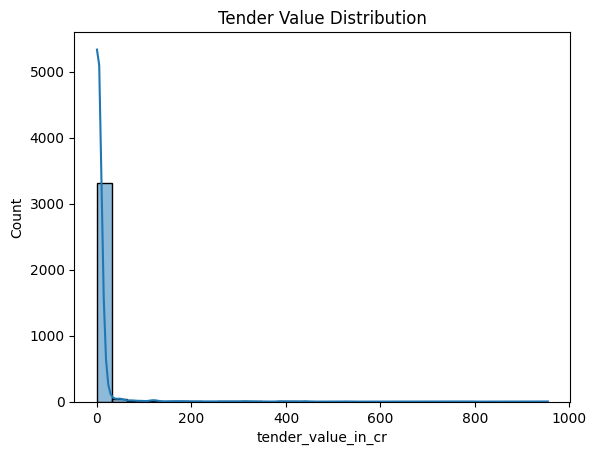

In [ ]:
sns.histplot(df['tender_value_in_cr'], bins=30, kde=True)
plt.title("Tender Value Distribution")
plt.show()

**Hitogram plot** shows the tender Value Distribution

**Features Used:** tender_value_in_cr

**Interpretation**
* Few tenders drive major value

# **Analysis by Main Procurement Category**

In [ ]:
df.groupby('main_procurement_category')['tender_value_in_cr'].agg(['count','sum','mean']).sort_values(by='mean',ascending=False)

,count,sum,mean
main_procurement_category,,,
Works,3106,21180.647021,6.819268
Goods,223,1411.180590,6.328164
Services,82,512.610201,6.251344


**Insight**

* Works category dominates with the highest number of tenders and total value, while Goods and Services contribute significantly less and have similar average values.

# **Analysis by Procurement Method**

In [ ]:
df.groupby('procurement_method')['tender_value_in_cr'].agg(['count','sum','mean']).sort_values(by='mean',ascending=False)

,count,sum,mean
procurement_method,,,
Global Tenders,2,818.902500,409.451250
Open Tender,3343,22125.414807,6.618431
Limited,41,154.551747,3.769555
Single,2,1.920000,0.960000
Open Limited,23,3.648757,0.158642


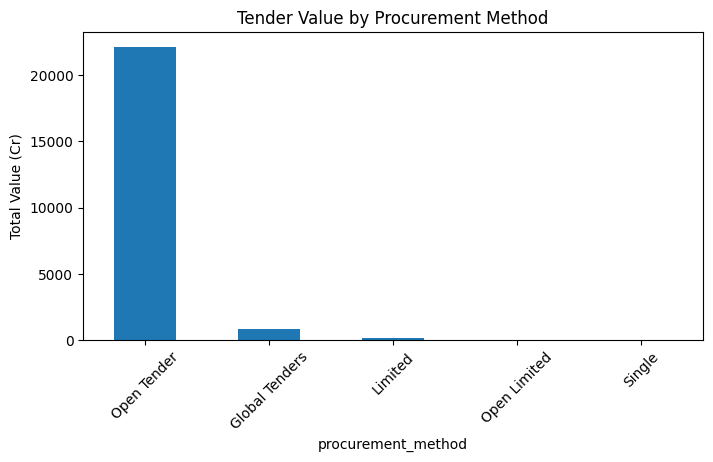

In [ ]:
plt.figure(figsize=(8, 4))
df.groupby('procurement_method')['tender_value_in_cr'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Tender Value by Procurement Method')
plt.ylabel('Total Value (Cr)')
plt.xticks(rotation=45)
plt.show()

**Barplot** showing the Tender Value by Procurement Method.

**Features used:** procrument_method, tender_value_in_cr.

**Insight**

* Open Tender has the highest number of tenders (3343) and total value (22,125 Cr)
* Global Tender has very few tenders (2) but very high average value (409 Cr)
* Limited and Open Limited methods have low count and very low total value
* Single tender method has almost no contribution overall

# **Analysis by Tender Classification**

In [ ]:
result=df.groupby('tender_classification')['tender_value_in_cr'].agg(['count','sum','mean']).sort_values(by='sum',ascending=False).head(10)
result

,count,sum,mean
tender_classification,,,
Civil Works - Building,505,8232.397671,16.301778
Civil Works,1450,6574.786415,4.534335
Electrical Works,342,1765.724466,5.162937
Civil Works – Roads,519,1425.069267,2.745798
Civil Works - Water Works,30,1074.202329,35.806744
Vehicles/Vehicle Spares,8,612.220459,76.527557
Construction Works,91,594.951852,6.537932
Composite Works,33,481.328452,14.585711
Supply of Materials,95,455.530575,4.795059


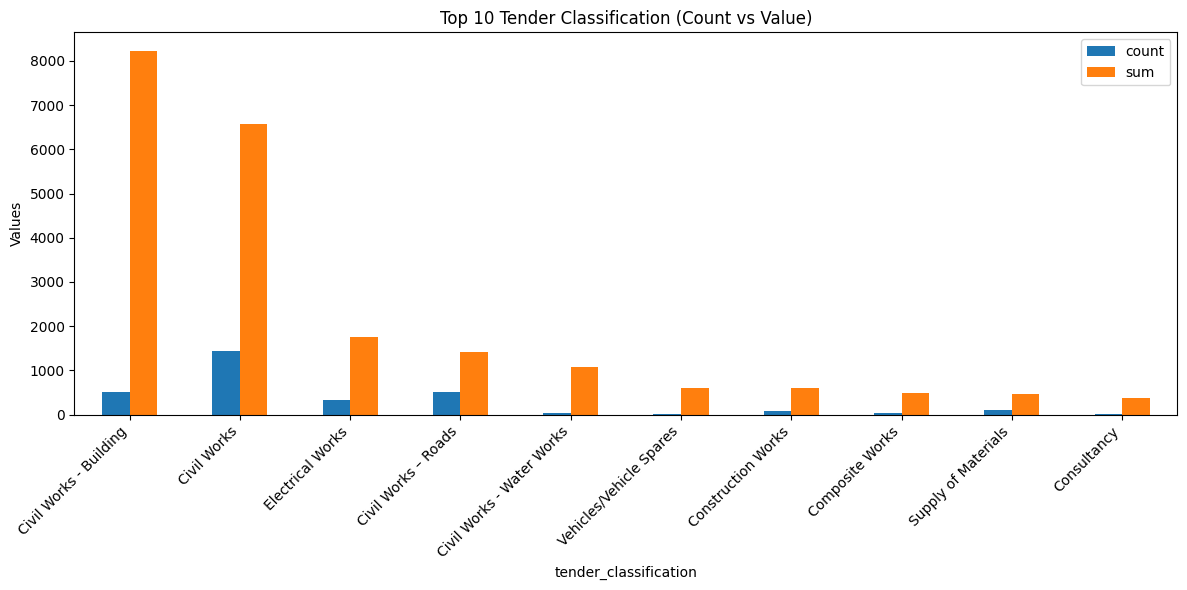

In [ ]:
result[['count','sum']].plot(kind='bar', figsize=(12,6))

plt.title('Top 10 Tender Classification (Count vs Value)')
plt.ylabel('Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Bar plot** showing total value of Top 10 tender classificaions

**Features Used:** tender_classification, tender_value_in_cr.

**Insight**

* Civil Works – Building has the highest total value, even with moderate count shows high-value projects.
* Civil Works has the highest number of tenders, but lower average value shows more frequent, smaller projects.
* Water Works and Consultancy has low count but high average value shows fewer but expensive tenders.
* Vehicles/Vehicle Spares has very high average value despite very few tenders shows specialized high-cost items.

#  **Analysis by Top buyers**

In [ ]:
total= df['tender_value_in_cr'].sum()

In [ ]:
result=df.groupby('buyer_name')['tender_value_in_cr'].agg(['sum','mean']).sort_values(by='sum',ascending=False).head(3)

In [ ]:
result['percentage'] = (result['sum'] / total) * 100
result

,sum,mean,percentage
buyer_name,,,
Public Works Building and NH Department,7885.526540,28.884713,34.129922
Public Works Roads Department,3821.786338,5.483194,16.541352
Public Works Roads Department-Externally Aided Project,2064.177600,114.676533,8.934117


In [ ]:
df['buyer_name'].value_counts().head(3)

,count
buyer_name,
Public Works Roads Department,697
Department of Water Resources,305
Public Works Building and NH Department,273


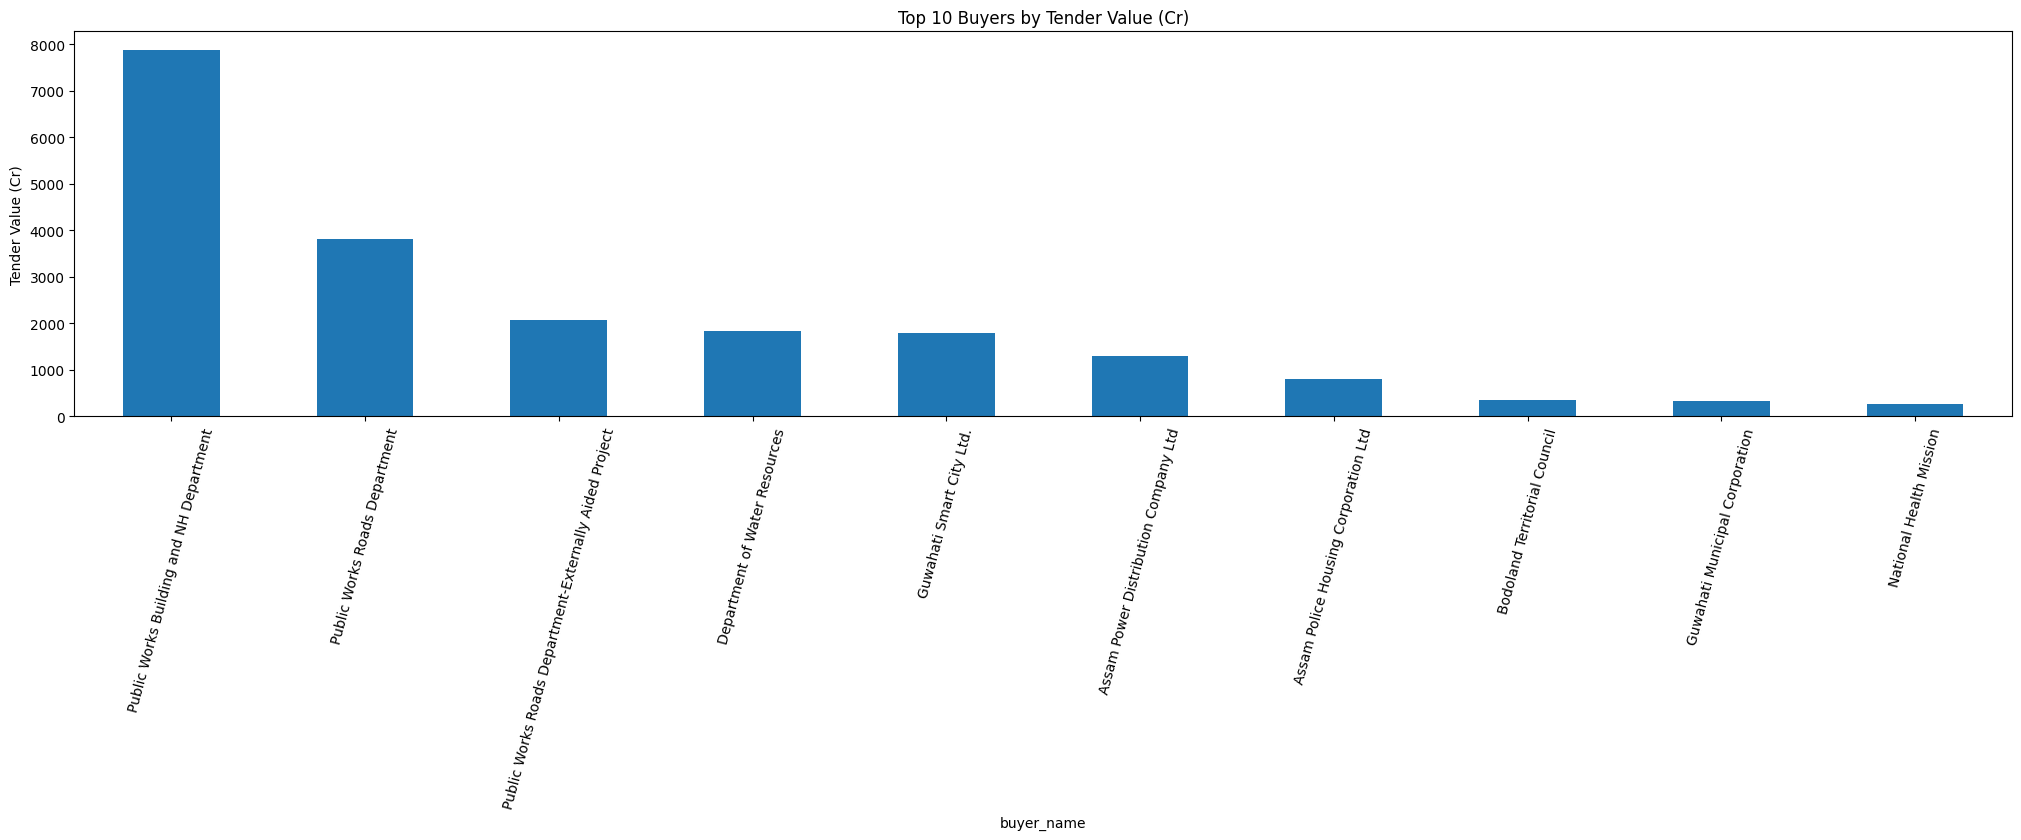

In [ ]:
top_buyers = df.groupby('buyer_name')['tender_value_in_cr'] \
    .sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(25, 5))
top_buyers.plot(kind='bar')

plt.title('Top 10 Buyers by Tender Value (Cr)')
plt.ylabel('Tender Value (Cr)')
plt.xticks(rotation=75)
plt.show()

**Bar plot** showing the total tender value for top 10 buyers

**Features Used:** buyer_name, tender_value_in_cr.

**Insight**

* The Public Works Building and NH Department has the highest total tender value, despite having a comparatively lower number of tenders, contributing about 34% of the total tender value.

* The Public Works Roads Department ranks next, with both a high total tender value and the highest number of tenders.
* The top buyer has a significantly higher value compared to others  shows imbalance.
* Remaining buyers contribute much less, indicating a skewed distribution.
* Overall: Tender value is not evenly distributed — it is concentrated among a few major buyers.

# **Tender Stage Distribution**

<Axes: xlabel='tender_stage'>

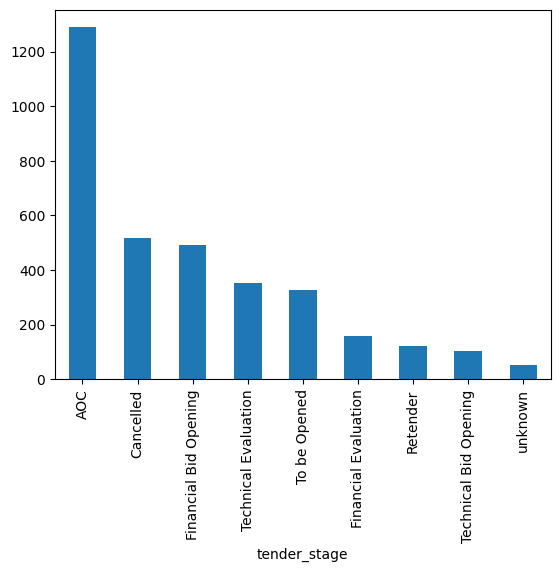

In [ ]:
df['tender_stage'].value_counts().plot(kind='bar')

**Bar Plot** shows the number of tenders across the each stage.

**Features Used:** tender_stage

**Interpretation**

* number of AOC which is successfully awarded is considerable.

# **Total Tender Value by Stage**

<Axes: xlabel='tender_stage'>

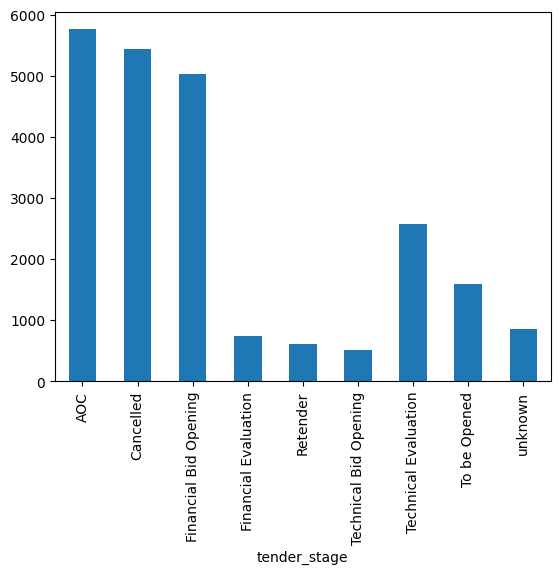

In [ ]:
df.groupby('tender_stage')['tender_value_in_cr'].sum().plot(kind='bar')

**Bar Plot** shows the tender value across each stage.

**Features Used:** tender_value_in_cr, tender_stage

**Interpretation**

* The value of tenders cancelled almost equal to the AOC.

* The higher value in Financial Bid opening shows that Large value tenders are struggling to progress towards the finalisation.

* next to that large value tenders are highly pending in technical evaluation.

# **Analysis of delay factor by tender stage**

In [ ]:
pending_stages=['Financial Bid Opening','Technical Evaluation','To be Opened','Financial Evaluation','Technical Bid Opening']

In [ ]:
pending=df[df['tender_stage'].isin(pending_stages)].groupby('tender_stage')['tender_value_in_cr'].agg(pending='count', total_value_in_cr='sum').sort_values(by='pending', ascending=False)
pending

,pending,total_value_in_cr
tender_stage,,
Financial Bid Opening,491,5026.145547
Technical Evaluation,352,2579.568107
To be Opened,325,1586.013473
Financial Evaluation,157,745.049877
Technical Bid Opening,103,502.818216


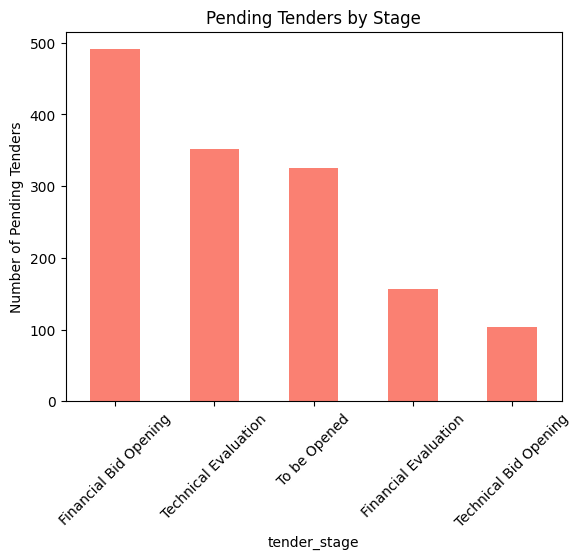

In [ ]:
pending['pending'].plot(kind='bar', color='salmon', title='Pending Tenders by Stage')
plt.ylabel('Number of Pending Tenders')
plt.xticks(rotation=45)
plt.show()

**Bar plot** shows number of pending tenders for each pending stages.

**Features Used:** tender_stage, tender_value_in_cr.

**Insight**

* Most delays happen in Financial Bid Opening (highest pending tenders).
* Technical Evaluation and To be Opened stages also show significant delays.
* Later stages like Financial Evaluation and Technical Bid Opening have fewer delays.
* This suggests delays mainly occur in mid-process stages, not at the beginning or end.
* The tender process bottleneck is mainly in evaluation and bid opening stages, indicating process inefficiency there.

# **Relationship between Tender Period and Tender Value**

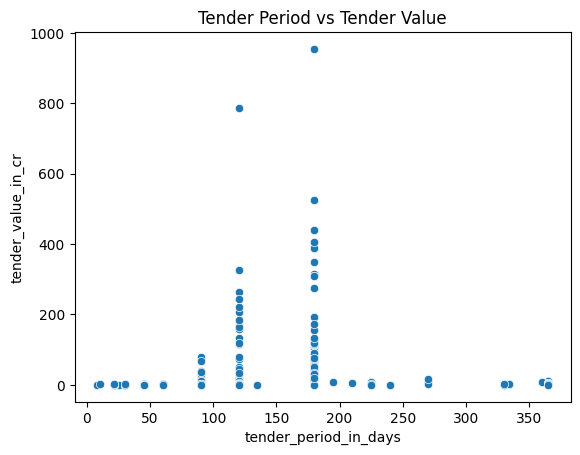

In [ ]:
sns.scatterplot(x='tender_period_in_days', y='tender_value_in_cr', data=df)
plt.title("Tender Period vs Tender Value")
plt.show()

**Scatter plot** showing tender period across the tender value.

**Features Used:** tender_period_in_days, tender_value_in_cr.

 **Interpretation**

* most of the tenders are observed around the 180-day duration

# **Correlation Analysis of Key Tender Variables**

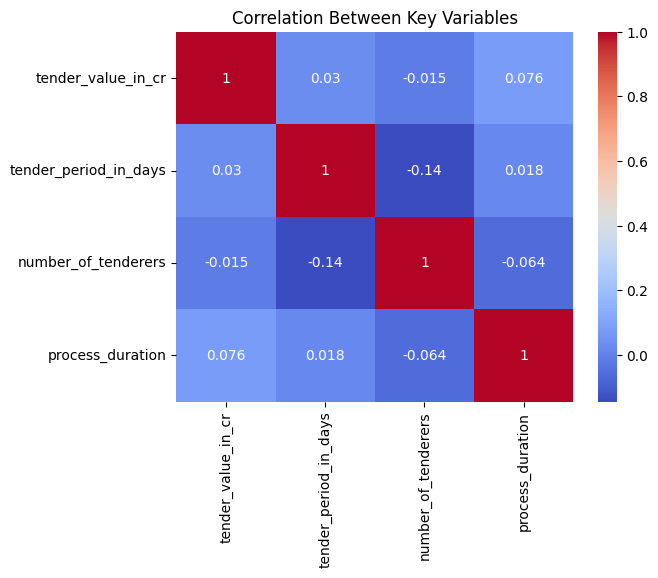

In [ ]:
num_cols = df[['tender_value_in_cr','tender_period_in_days','number_of_tenderers','process_duration']]

corr = num_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Key Variables')
plt.show()

**Scatter plot** Heat map shows that the co-relation between key variables.

**Features Used:** tender_value_in_cr, tender_period_in_days, number_of_tenderers, process_duration

 **Interpretation**
* No strong correlation between variables

* Tender value is not related to duration or bidders

* Delays are likely due to process-related factors

## **Download cleaned data for dashboard creation using Power BI**

In [ ]:
import pandas as pd

df.to_csv("tender_process_in_public_procrument.csv", index=False)

##**Stage 4 – Documentation, Insights and Presentation**



#**Dashboard**

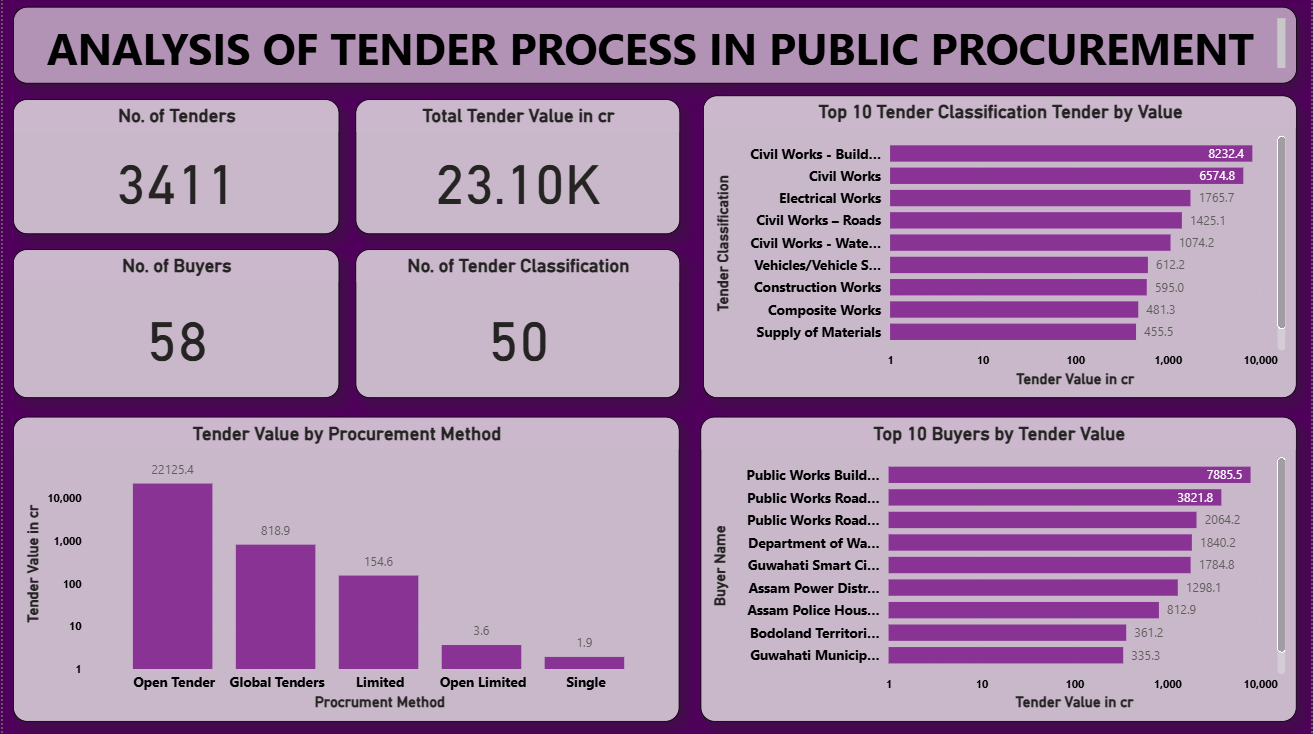

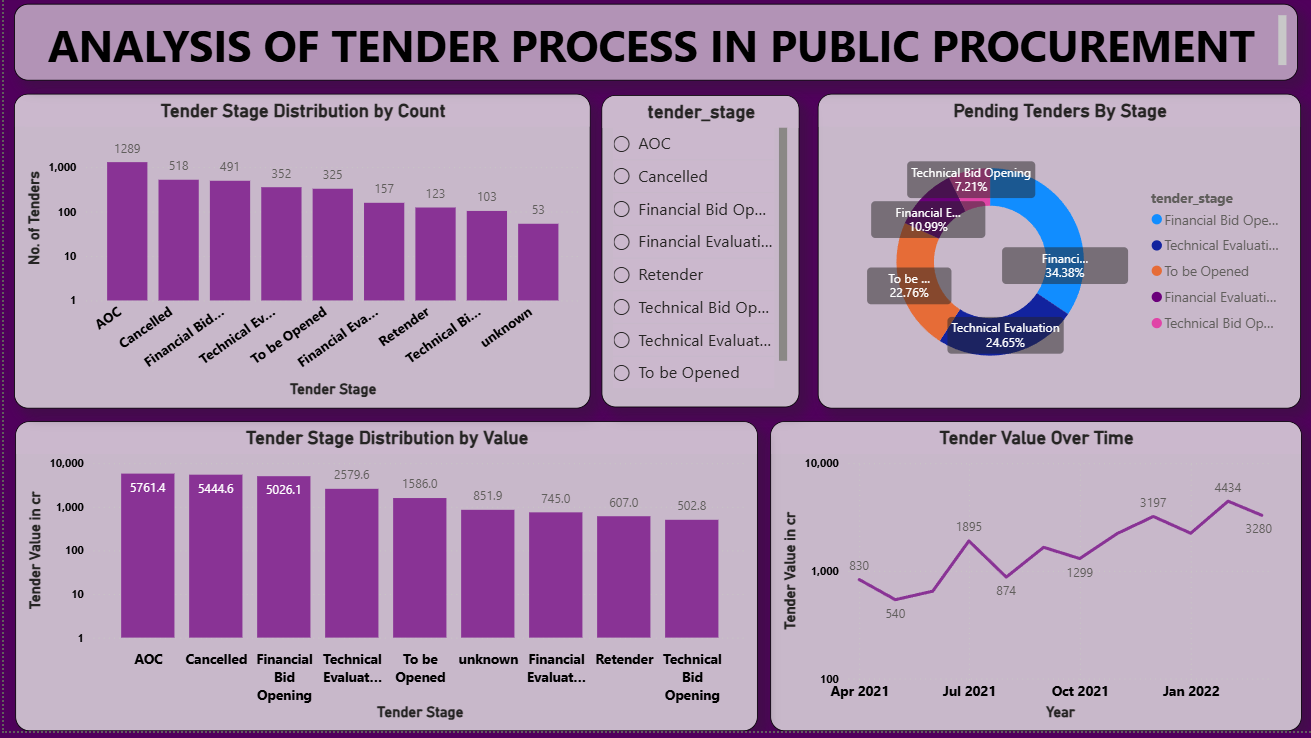

#**Summary**

* The analysis shows that tender values are highly skewed, with a few tenders contributing a major share of the total value. The Works category dominates both in number of tenders and overall value. Among procurement methods, Open Tenders account for the majority (3343 tenders), whereas Global Tenders, though very few, have significantly higher average values.

* Buyer-wise analysis reveals that a small number of departments contribute a large portion of the total tender value, with the top buyer contribute a significant share of total tender value, indicating strong concentration.

* Stage-wise analysis highlights that while many tenders reach the final stage (AOC), a significant number remain pending in Financial Bid Opening and Technical Evaluation, indicating process bottlenecks.

* Additionally, correlation analysis shows no strong relationship between tender value, duration, and number of bidders, suggesting that delays are influenced more by process-related factors than by these variables.

#**Key Insights**

* The Works category dominates both in number of tenders and total value, indicating major focus on infrastructure-related projects.

* Public Works Building and NH Department contributes the highest tender value, showing that tender value is concentrated among a few key buyers.

* Open Tender method accounts for the majority of tenders, while Global Tenders, though very few (2), have very high average value, contributing to the skewness in overall tender value distribution.

* A considerable number of tenders are concentrated in mid-process stages, indicating delays in progression toward finalization.

* The total value of cancelled and retendered tenders is nearly equal to AOC, indicating significant rework and inefficiencies in the process

* There is no strong correlation between tender value, duration, and number of bidders

#**Business Recommendations**

* Improve efficiency in Financial Bid Opening and Technical Evaluation stages by streamlining approval and review processes.

* Implement better tracking and monitoring systems to identify and reduce delays in mid-process stages.

* For high-value tenders, increase participation by attracting more qualified bidders through wider publicity, transparency, and clear requirements

* Ensure better planning and coordination for large and complex tenders to avoid unnecessary delays

* Use historical data insights to optimize tender planning and decision-making

#**Final Story of the Report**

* The tender process is largely driven by infrastructure-related projects, with value concentrated among a few key buyers.

* While the system shows strong activity, most tenders follow standard procurement methods with limited variation.

* A significant portion of tenders face delays in mid-process stages, affecting smooth progression.

* Frequent cancellations and few retenders indicate rework and scope for improvement in initial planning.

* Overall, the process is active but requires better efficiency and control to improve outcomes

#**Conclusion**

* The tender process shows strong activity, with high concentration of value in infrastructure projects and key buyers.

* While many tenders reach completion, a notable number of cancellations impact overall efficiency, whereas retenders are comparatively few.

* The absence of strong relationships between key variables indicates that process-related factors play a major role.

* Improving process efficiency by streamlining evaluation stages(faster approvals, clear timelines) and enhancing monitoring of mid-process stages can help reduce delays and improve overall outcomes